In [ ]:
# Cài đặt các thư viện cần thiết
!pip install -q diffusers transformers accelerate torch opencv-python rembg torchmetrics
!pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00


✅ Đã tìm thấy file LoRA.
⏳ Đang tải model (DreamShaper v8 Base)...


model_index.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/520 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

📸 Ảnh 3: Score = 37.00


  0%|          | 0/30 [00:00<?, ?it/s]

📸 Ảnh 4: Score = 31.95


  0%|          | 0/30 [00:00<?, ?it/s]

📸 Ảnh 5: Score = 34.48


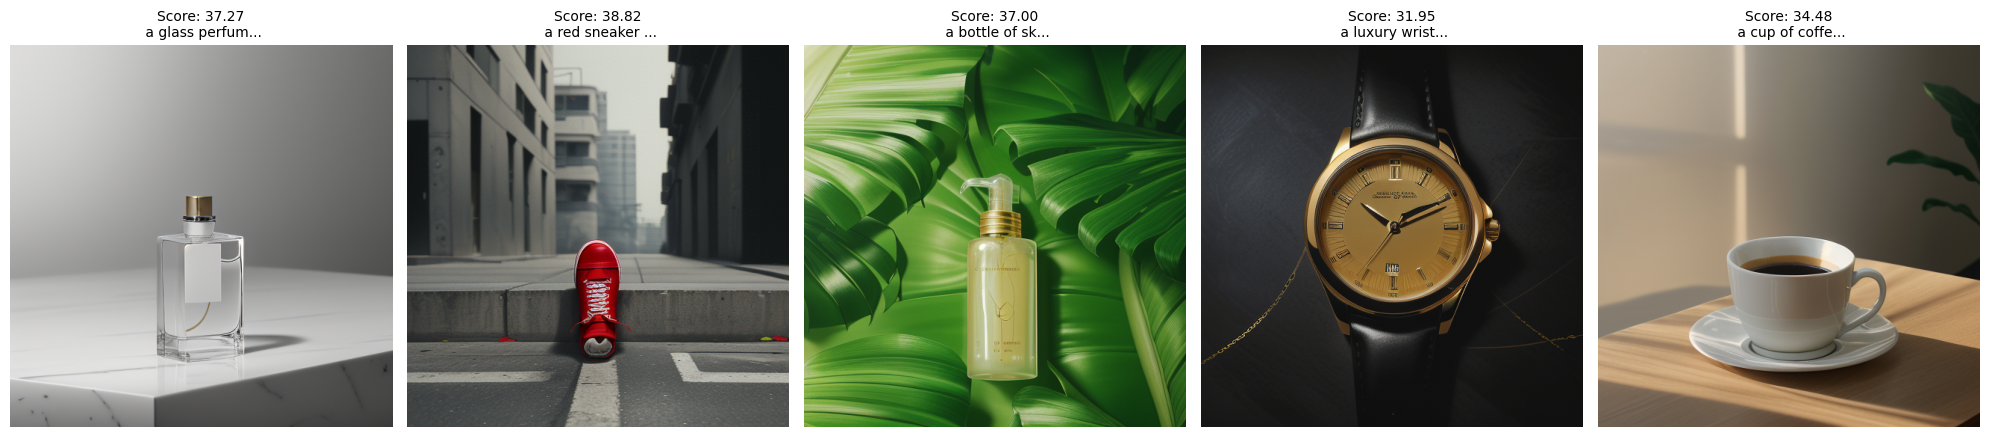


📊 KẾT QUẢ ĐÁNH GIÁ TRUNG BÌNH (CLIP SCORE)
➡️ Average Score: 35.9049


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler
from torchmetrics.multimodal.clip_score import CLIPScore
from google.colab import drive

# --- 1. KẾT NỐI DRIVE ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# ⚠️ ĐƯỜNG DẪN FILE LORA CỦA BẠN ⚠️
LORA_PATH = "/content/drive/MyDrive/Loras/prostudio/output/prostudio-10.safetensors"

if not os.path.exists(LORA_PATH):
    print(f"❌ LỖI: Không tìm thấy file tại {LORA_PATH}")
else:
    print(f"✅ Đã tìm thấy file LoRA.")

    # --- 2. CẤU HÌNH & LOAD MODEL ---
    TRIGGER = "prostudio style"
    test_prompts = [
        f"{TRIGGER}, a glass perfume bottle on a white marble podium, soft studio lighting, minimalist",
        f"{TRIGGER}, a red sneaker shoe on a concrete street background, urban style, cinematic lighting",
        f"{TRIGGER}, a bottle of skincare serum surrounded by green tropical leaves, nature background, sunlight",
        f"{TRIGGER}, a luxury wrist watch on black velvet texture, golden rim light, premium look",
        f"{TRIGGER}, a cup of coffee on a wooden table, morning sunlight, cozy atmosphere"
    ]

    print("⏳ Đang tải model (DreamShaper v8 Base)...")
    # 👉 ĐÃ SỬA: Dùng model chuẩn (Lykon/dreamshaper-8) thay vì bản inpainting
    pipe = StableDiffusionPipeline.from_pretrained(
        "Lykon/dreamshaper-8",
        torch_dtype=torch.float16,
        safety_checker=None
    ).to("cuda")

    # Dùng Euler Scheduler cho ổn định
    pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)

    # Load LoRA
    try:
        pipe.load_lora_weights(LORA_PATH)
        pipe.fuse_lora()
        print("✅ Đã nạp LoRA thành công!")
    except Exception as e:
        print(f"⚠️ Lỗi nạp LoRA: {e}")

    # Khởi tạo máy chấm điểm
    metric = CLIPScore(model_name_or_path="openai/clip-vit-base-patch16")

    # --- 3. CHẠY THỰC NGHIỆM ---
    scores = []
    print("\n--- BẮT ĐẦU SINH ẢNH & CHẤM ĐIỂM ---")

    plt.figure(figsize=(20, 6))
    for i, prompt in enumerate(test_prompts):
        # Sinh ảnh với seed cố định
        generator = torch.Generator("cuda").manual_seed(42)

        image = pipe(
            prompt,
            num_inference_steps=30,
            guidance_scale=7.5,
            generator=generator
        ).images[0]

        # Chấm điểm
        img_array = np.array(image)
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)

        # Tính CLIP Score
        score = metric(img_tensor, prompt).item()
        scores.append(score)

        # Hiển thị
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Score: {score:.2f}\n{prompt.split(',')[1][:15]}...", fontsize=10)
        print(f"📸 Ảnh {i+1}: Score = {score:.2f}")

    plt.tight_layout()
    plt.show()

    # --- 4. TỔNG KẾT ---
    avg_score = sum(scores) / len(scores)
    print("\n" + "="*50)
    print(f"📊 KẾT QUẢ ĐÁNH GIÁ TRUNG BÌNH (CLIP SCORE)")
    print(f"➡️ Average Score: {avg_score:.4f}")
    print("="*50)

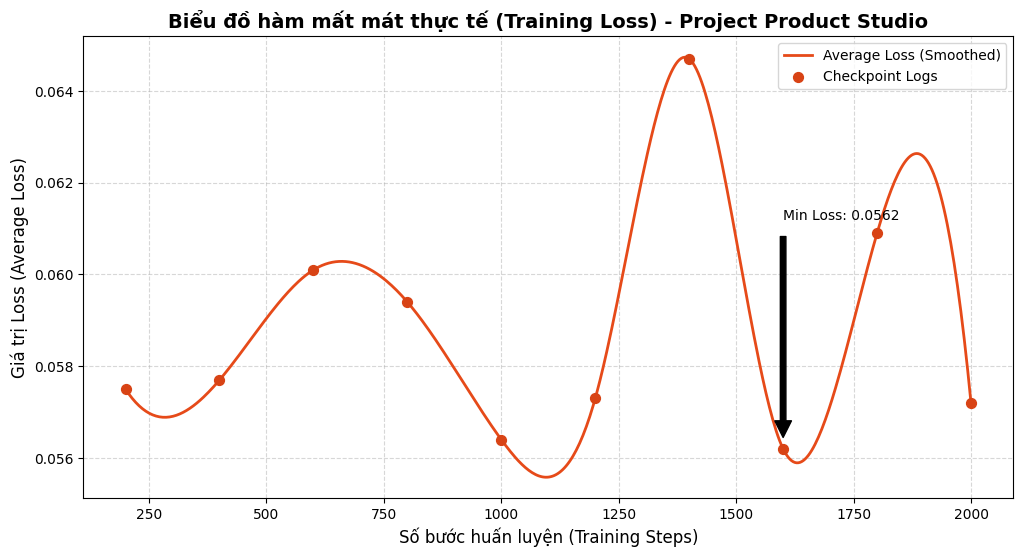

✅ Đã vẽ xong! Hãy tải file 'real_training_loss.png' về đưa vào báo cáo.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Dữ liệu thực tế trích xuất từ Log của bạn
steps = np.array([200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000])
loss_values = np.array([0.0575, 0.0577, 0.0601, 0.0594, 0.0564, 0.0573, 0.0647, 0.0562, 0.0609, 0.0572])

# 2. Làm mượt đường biểu đồ cho đẹp (Smoothing)
# Tạo thêm các điểm giữa để đường cong mềm mại hơn
X_Y_Spline = make_interp_spline(steps, loss_values)
X_ = np.linspace(steps.min(), steps.max(), 500)
Y_ = X_Y_Spline(X_)

# 3. Vẽ biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ đường Loss chính (Màu đỏ cam)
plt.plot(X_, Y_, color='#E64A19', linewidth=2, label='Average Loss (Smoothed)')

# Vẽ các điểm dữ liệu thực (Chấm tròn)
plt.scatter(steps, loss_values, color='#D84315', s=50, zorder=5, label='Checkpoint Logs')

# Trang trí biểu đồ chuẩn báo cáo
plt.title('Biểu đồ hàm mất mát thực tế (Training Loss) - Project Product Studio', fontsize=14, fontweight='bold')
plt.xlabel('Số bước huấn luyện (Training Steps)', fontsize=12)
plt.ylabel('Giá trị Loss (Average Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Hiển thị giá trị thấp nhất
min_loss = min(loss_values)
min_step = steps[np.argmin(loss_values)]
plt.annotate(f'Min Loss: {min_loss}', xy=(min_step, min_loss), xytext=(min_step, min_loss+0.005),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

# Lưu và hiển thị
plt.savefig("real_training_loss.png", dpi=300)
plt.show()

print("✅ Đã vẽ xong! Hãy tải file 'real_training_loss.png' về đưa vào báo cáo.")